<center><h1> Three-Eloop </h1></center>

In [7]:
from MCA_lib1_2 import *
import pennylane as qml
import warnings
warnings.filterwarnings('ignore')

## Variables Input

In [8]:
# Number of desired symbols
num_ext_edges=4
num_int_edges=5
num_edges =num_ext_edges+num_int_edges

num_no_reverse_clauses = 13

num_propagator_edge = 2

needs_extra_qubit = True

name_diagram = '4s18t'

num_shots = 30000000

cut = 40

## Logical Variables

In [9]:
# Lista para almacenar los símbolos con subíndices
S = make_edges(num_edges)
Sp = make_prime_edges(S)

Set_edges = make_set_edges(S,Sp)

# Ancilla qubits

c = [symbols('c_{}'.format(i)) for i in range(0, num_no_reverse_clauses)]

## Llenado de Ancilla qubits y creación de resultados

In [10]:
# Definir auxiliares
c[0] = And(S[0], S[1], S[2], S[3])

c[1] = And(S[0],Sp[4], S[5],Sp[8])

c[2] = And(S[1],Sp[5],S[6]) #13

c[3] = And(S[2], Sp[6], S[7], S[8]) #14

c[4] = And(S[3], S[4], Sp[7]) #15

c[5] = And(S[0],S[1], Sp[4], S[6],Sp[8])

c[6] = And(S[1],S[2], Sp[5], S[7],S[8]) #16

c[7] = And(S[2],S[3], S[4], Sp[6],S[8]) #17

c[8] = And(S[0],S[3], S[5], Sp[7],Sp[8])

c[9] = And(S[0],S[1], S[2], Sp[4], S[7])

c[10] = And(S[1],S[2], S[3], S[4],Sp[5],S[8]) #18

c[11] = And(S[0],S[2], S[3], S[5], Sp[6])

c[12] = And(S[0],S[1], S[3], S[6],Sp[7],Sp[8])





######################## Total ######################

clauses = [*c, *reverse_clauses(c, S, Sp)]

## Matriz de adyacencia - Clausulas

In [11]:
Graph_matrix_clauses = adjacent_matrix_clauses(clauses, Set_edges)
Graph_matrix_clauses

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
        1., 1., 1.],
       [0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0.],
       [0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0.,
        1., 0., 1.],
       [0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0.,
        1., 1., 1.],
       [0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
        0., 1., 1.],
       [0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0.,
        1., 0., 1.],
       [0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0.,
        1., 1., 1.],
       [0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1.,
        1., 1., 1.],
       [0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 1.,
        0., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0.,
        1., 1., 1.],
       [0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1.

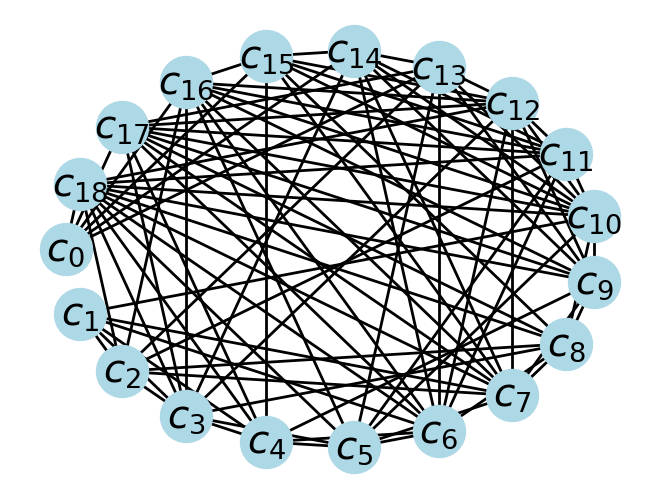

In [12]:
graph_clauses = graph_clauses(clauses, Set_edges, draw = True, name_graph = '3e9_clauses')

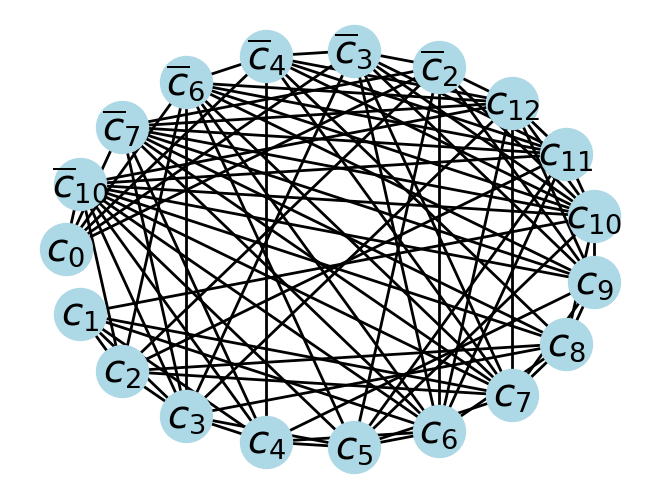

In [13]:
graph_clausesR = graph_clauses_Rev(S,c,clauses, Set_edges, draw = True, name_graph = '3e9_ClausesRev')

[[10, 9, 12, -7, -2], [-6, 5, 11, 6], [3, 2, 8, -10], [-4, -3, 0], [1, 4], [7]]

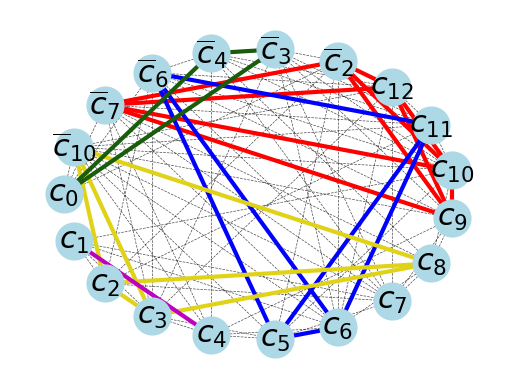

In [14]:
graph_clausesC = graph_clauses_C(S,c,clauses, Set_edges, draw = True, name_graph = '3e9_Clauses_cliques')
graph_clausesC[1]

In [15]:
clauses_combination = Graph_condition_combination(graph_clauses,clauses,S,c)
clauses_combination

([[10, 9, 12, 17, 13],
  [16, 5, 11, 6],
  [3, 2, 8, 18],
  [15, 14, 0],
  [1, 4],
  [7]],
 [[10, 9, 12, -7, -2],
  [-6, 5, 11, 6],
  [3, 2, 8, -10],
  [-4, -3, 0],
  [1, 4],
  [7]])

## Depth

In [16]:
Graph_matrix_depth = adjacent_matrix_depth(clauses, Set_edges)

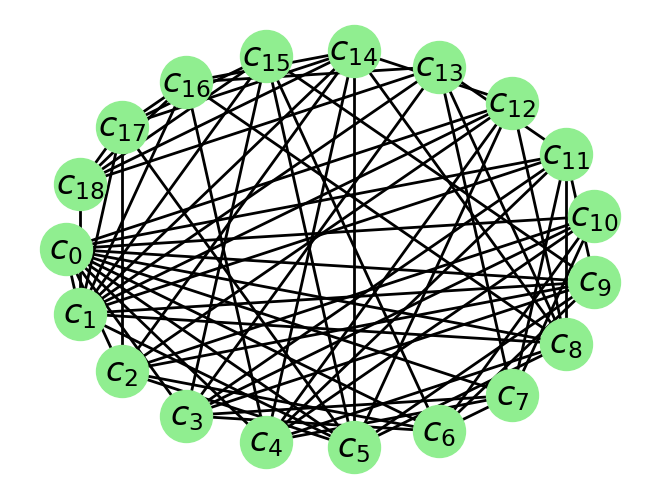

In [17]:
graph_depth = graph_depth(clauses, Set_edges, draw = True, name_graph = 'xmen_depht')

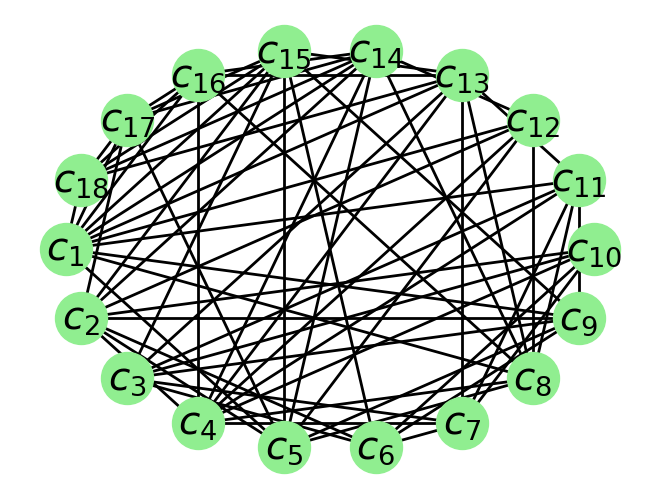

In [18]:
graph_depth3 = graph_depth3(clauses,num_ext_edges ,Set_edges, draw = True)

[[0], [1, 5, -3, 12, 8], [2, 6, 9, -4], [-2, 3, 11, 7], [-6, -7, -10], [10, 4]]

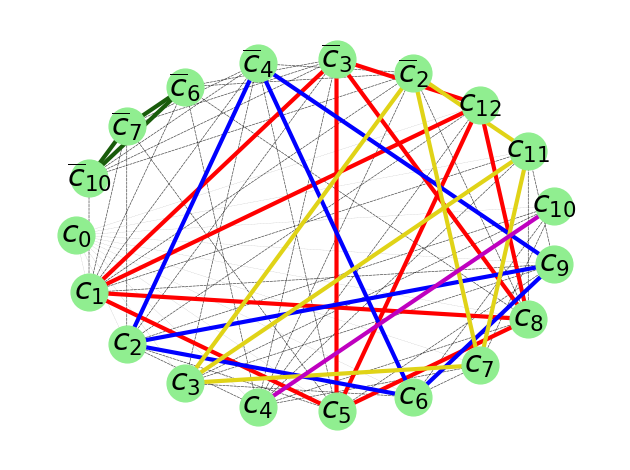

In [19]:
graph_depthf=graph_depthC(S,c,clauses,num_ext_edges,Set_edges, draw = True,name_graph = '3e9')
graph_depthf[1]

In [20]:
depth_combination = Graph_condition_combination(graph_depth,clauses,S,c)
depth_combination

([[0, 7, 3, 10, 6],
  [1, 5, 14, 8, 12],
  [15, 18, 17],
  [16, 4],
  [9, 2],
  [11, 13]],
 [[0, 7, 3, 10, 6],
  [1, 5, -3, 8, 12],
  [-4, -10, -7],
  [-6, 4],
  [9, 2],
  [11, -2]])

In [21]:
depth_combination3 = Graph_condition_combination3(graph_depth3,clauses, num_ext_edges,S,c)
depth_combination3
#[[3], [0, 4], [1, 5], [2]]


([[0],
  [1, 5, 14, 12, 8],
  [2, 6, 9, 15],
  [13, 3, 11, 7],
  [16, 17, 18],
  [10, 4]],
 [[0],
  [1, 5, -3, 12, 8],
  [2, 6, 9, -4],
  [-2, 3, 11, 7],
  [-6, -7, -10],
  [10, 4]])

<left><h2> Qubits </h2></left>

In [22]:
# Numbers of qubits to use
num_auxs = len(clauses_combination[0])

# Qubits
edges_to_propag, e = edges_to_propagators(S, num_propagator_edge = num_propagator_edge)
clauses_to_aux,a = clauses_auxiliar(clauses, clauses_combination[0])

mark = 'out'


# Wires

total_wires = [*e, *a, mark]
init_states_wires = e

multi_controll_wires = [e[0], *a, mark]

if needs_extra_qubit:
    extra = 'extra'
    total_wires.insert(0, extra)
    init_states_wires.insert(0, extra)
    multi_controll_wires.insert(0, extra)

# Circuit

In [23]:
dev = qml.device('default.qubit', wires = total_wires, shots = num_shots)
qml.templates.GroverOperator.__name__ = "Diffusion Operator"

def circuit_function(depth_combination3):
    @qml.transforms.cancel_inverses
    @qml.qnode(dev)
    def circuit():
        #State preparation
        qml.broadcast(qml.Hadamard, init_states_wires, 'single')
        qml.broadcast(qml.PauliX, a, 'single')
        qml.PauliX(wires = mark)
        qml.Hadamard(wires = mark)
        # Oracle
        oracle(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        #
        qml.MultiControlledX(wires = multi_controll_wires)
        # Adjoint Oracle
        qml.simplify(qml.adjoint(oracle))(clauses, edges_to_propag, clauses_to_aux, S, Sp, depth_combination3)
        # Grover Diffuser
        qml.templates.GroverOperator(wires=init_states_wires)
        return qml.counts(wires = init_states_wires)
    return circuit

In [24]:
circuit3 = circuit_function([[0], [11, 3, 13, 7], [4, 10], [6, 15, 2, 9], [5, 8, 12, 14, 1], [18, 17, 16]])

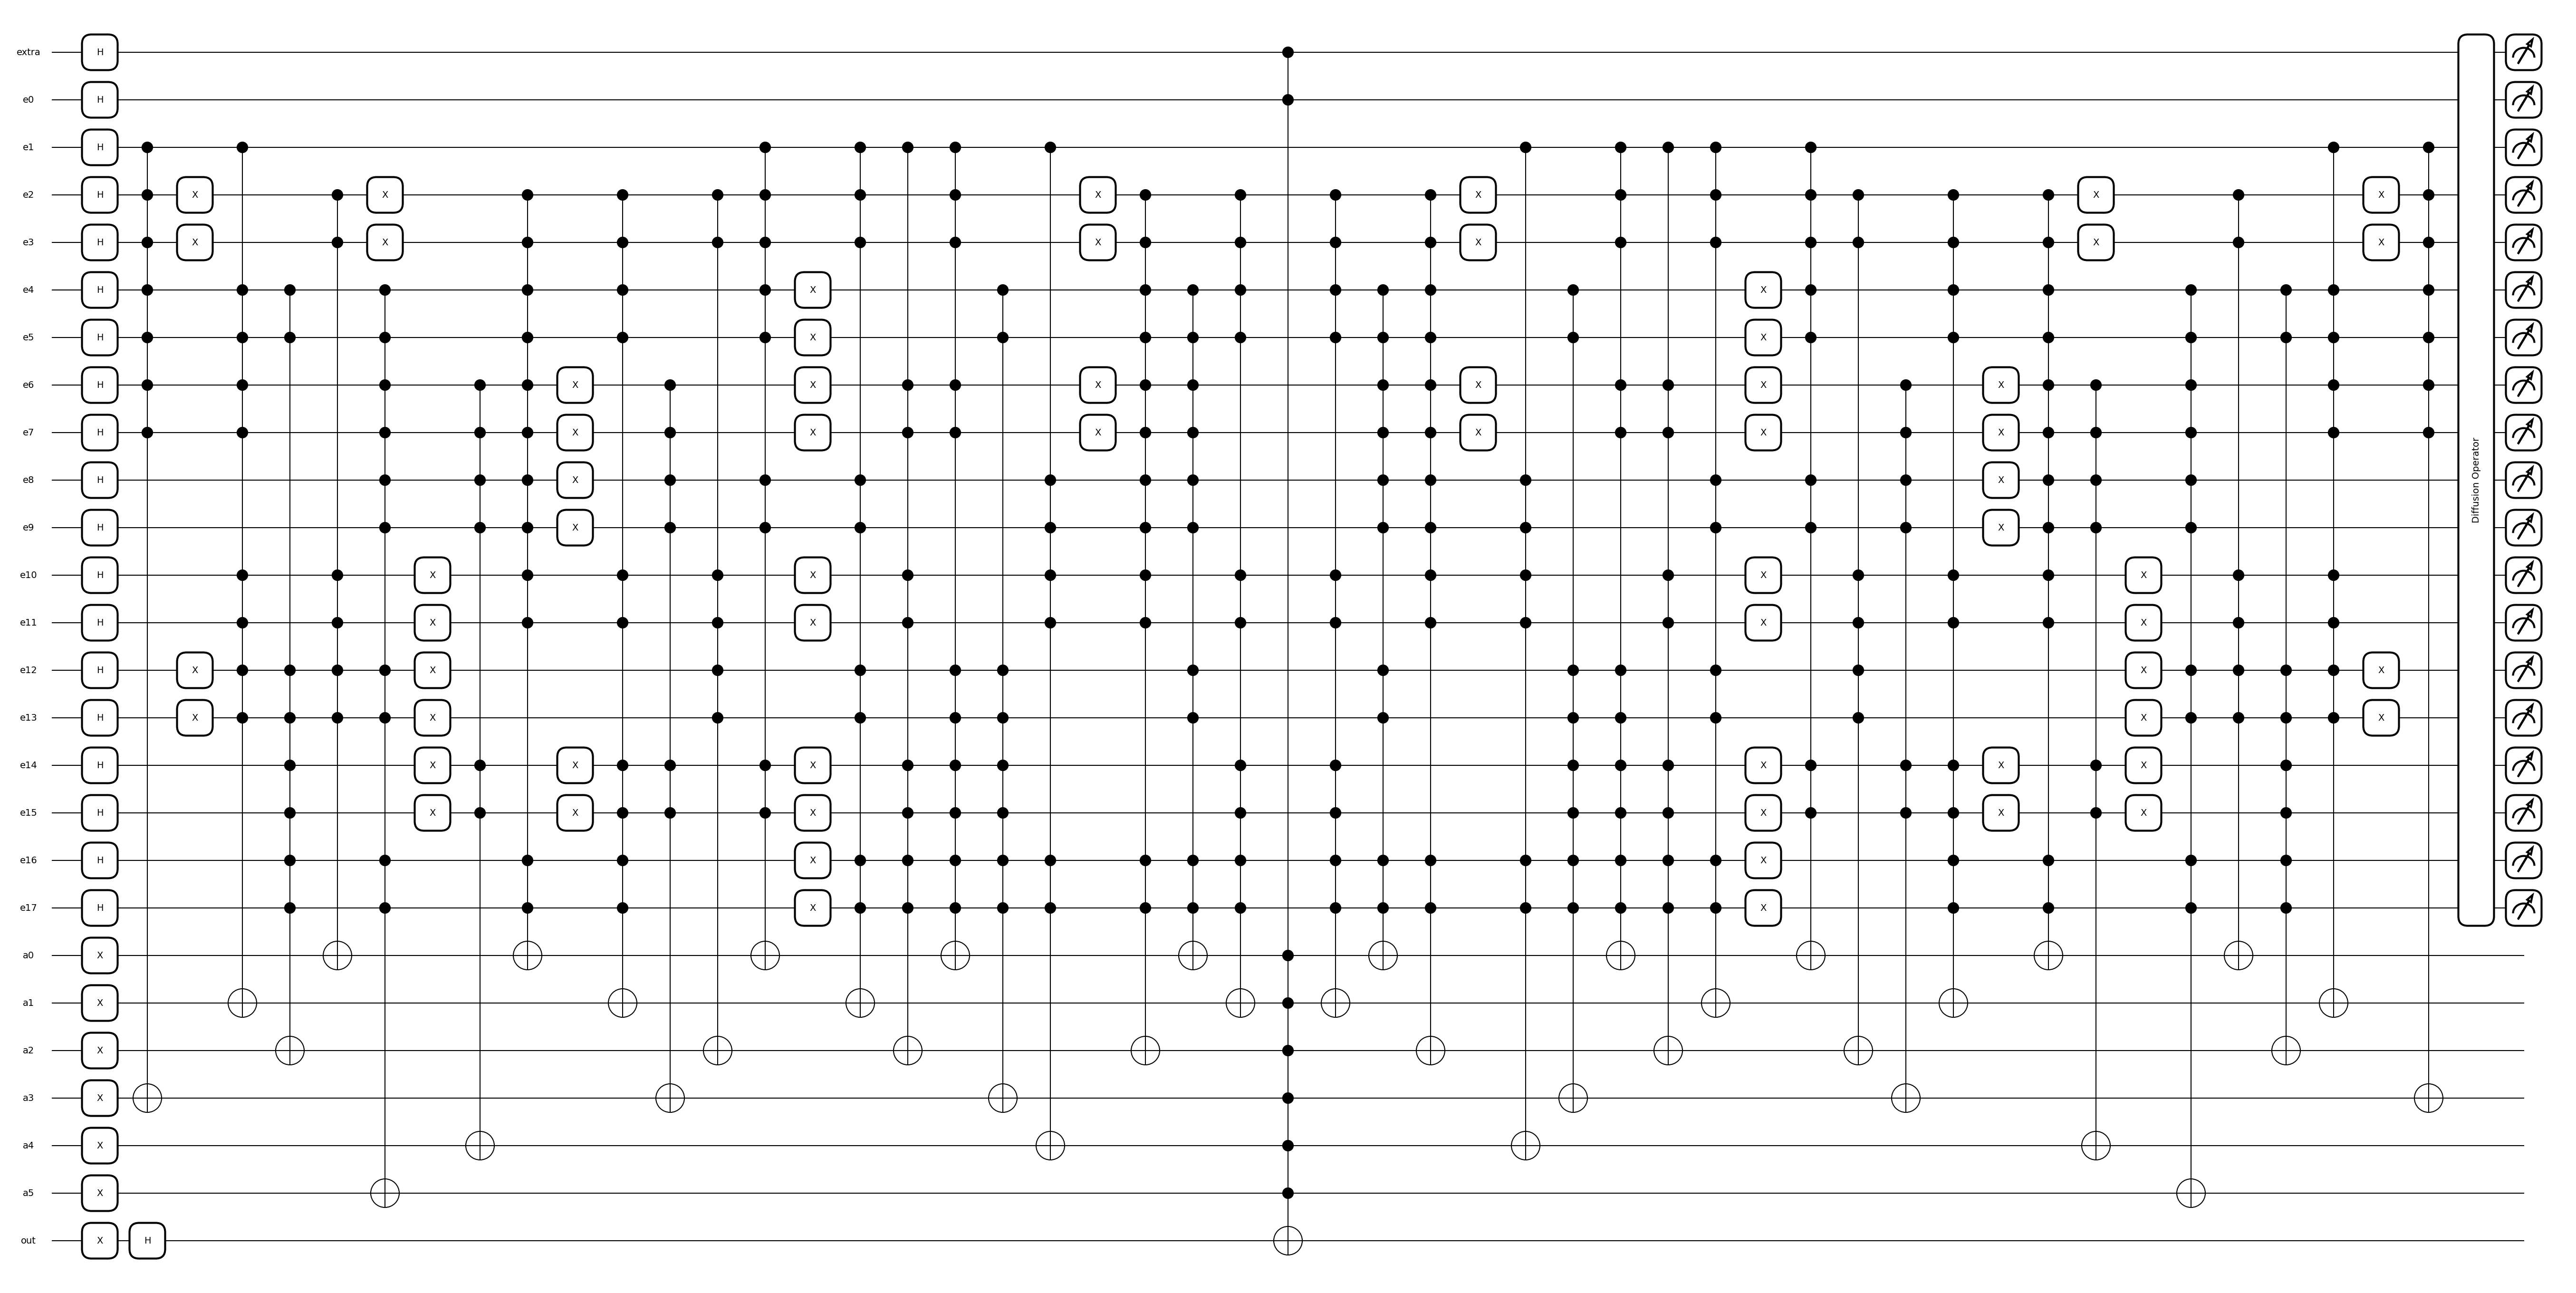

In [25]:
Draw_circuit(circuit3, wire_order_list= total_wires, name_file = name_diagram)

In [26]:
get_depth(circuit3)

The depth of the circuit is: 39


In [27]:
#num_casual_states(circuit3(), cut = 300)

# Optimization

## OPTUNA

In [28]:
import itertools
import optuna
import math

# List of original subsets
subconjuntos_base = depth_combination3[0]


# Precomputes the permutations of each subset (as a list of tuples)
permutaciones_por_subconjunto = [
    list(itertools.permutations(sub)) for sub in subconjuntos_base
]

# Precomputes the number of permutations of each subset
num_permutaciones = [len(p) for p in permutaciones_por_subconjunto]

# Total amount of permutations with a subset order fixed
total_comb_internas = math.prod(num_permutaciones)

# Amount of subset permutations
total_ordenes = math.factorial(len(subconjuntos_base))

# Total amount of possible permutations (not all permutations are generated)
espacio_total = total_comb_internas * total_ordenes

# Función ficticia a optimizar (reemplaza esto con tu lógica real)
def depth_circuit(depth_combination3):
    circuit = circuit_function(depth_combination3)     
    return qml.specs(circuit)()['resources'].depth

# Decodificar un índice entero único en una combinación (sin generar todas)
def decodificar_combinacion(idx):
    n = len(subconjuntos_base)

    # Obtener el orden de los subconjuntos (perm index → permutación)
    orden_idx = idx % total_ordenes
    comb_idx = idx // total_ordenes

    orden = list(itertools.permutations(range(n)))[orden_idx]

    # Decodes internal indices for each subset
    indices_internos = []
    for i in reversed(range(n)):
        p = num_permutaciones[i]
        indices_internos.append(comb_idx % p)
        comb_idx //= p
    indices_internos = list(reversed(indices_internos))

    # Constructs the last combination
    combinacion = [list(permutaciones_por_subconjunto[i][indices_internos[i]]) for i in orden]
    return combinacion

# Función de evaluación para Optuna
def objective(trial):
    idx = trial.suggest_int("idx", 0, espacio_total - 1)
    combinacion = decodificar_combinacion(idx)
    return depth_circuit(combinacion)

# Executes the optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=2000)  # Adjust the number of trials

# Shows the best value
best_idx = study.best_params["idx"]
best_combination = decodificar_combinacion(best_idx)
print("Best combination:", best_combination)
print("Minimum value:", study.best_value)


[I 2026-04-22 15:12:26,902] A new study created in memory with name: no-name-4e65ac48-573e-4905-b010-dfe595242b92
[I 2026-04-22 15:12:26,928] Trial 0 finished with value: 47.0 and parameters: {'idx': 55005482}. Best is trial 0 with value: 47.0.
[I 2026-04-22 15:12:26,955] Trial 1 finished with value: 45.0 and parameters: {'idx': 369368404}. Best is trial 1 with value: 45.0.
[I 2026-04-22 15:12:26,988] Trial 2 finished with value: 45.0 and parameters: {'idx': 486628520}. Best is trial 1 with value: 45.0.
[I 2026-04-22 15:12:27,013] Trial 3 finished with value: 47.0 and parameters: {'idx': 559183074}. Best is trial 1 with value: 45.0.
[I 2026-04-22 15:12:27,044] Trial 4 finished with value: 49.0 and parameters: {'idx': 536619691}. Best is trial 1 with value: 45.0.
[I 2026-04-22 15:12:27,072] Trial 5 finished with value: 47.0 and parameters: {'idx': 574127733}. Best is trial 1 with value: 45.0.
[I 2026-04-22 15:12:27,102] Trial 6 finished with value: 49.0 and parameters: {'idx': 127882272

Best combination: [[0], [10, 4], [8, 12, 1, 14, 5], [9, 15, 2, 6], [7, 11, 3, 13], [18, 16, 17]]
Minimum value: 39.0


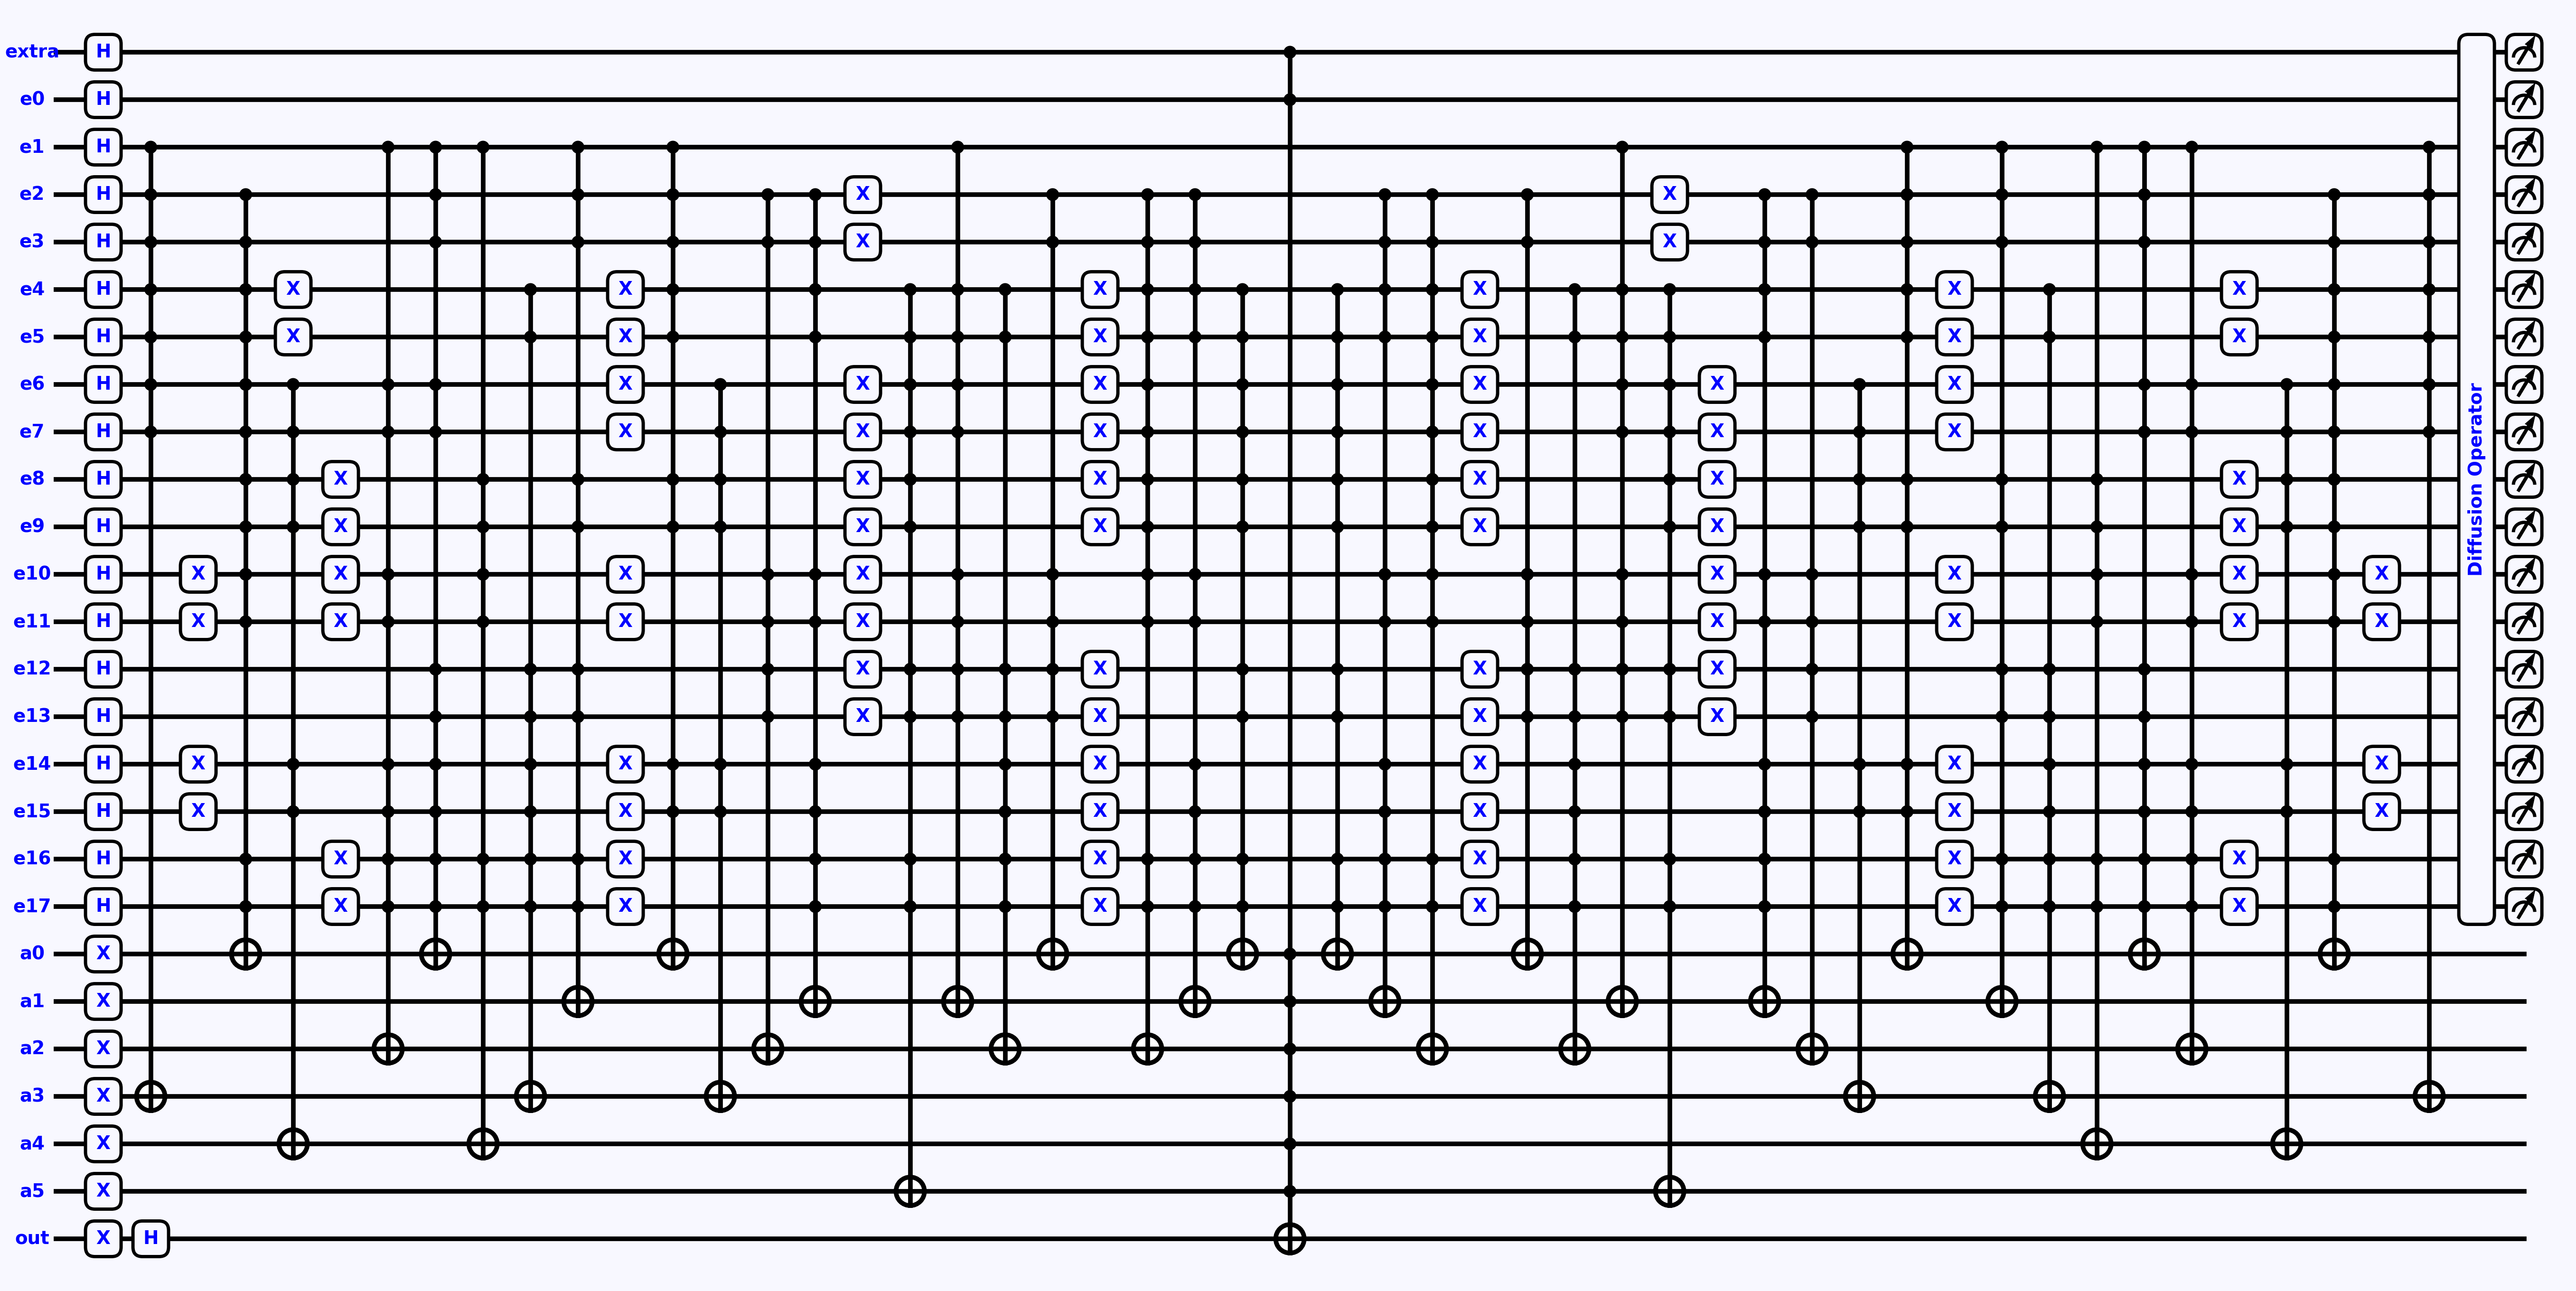

The depth of the circuit is: 39


In [29]:
circuit_D = circuit_function(best_combination)
Draw_circuit2(circuit_D, wire_order_list= total_wires, name_file = name_diagram)
get_depth(circuit_D)